In [2]:
import numpy as np

results = np.load("data_Gauss/results_optim.npy", allow_pickle=True).item()

vec_U = results['vec_U']
vec_n_photon = results['vec_n_photon']
vec_n_out = results['vec_target_n_out']
gammas = results['gammas']

print(f"U: {vec_U}")
print(f"n_photon: {vec_n_photon}")
print(f"n_out contstraint: {vec_n_out}")
print(f"gammas: {gammas}")

U: [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
n_photon: [  1.           1.09854114   1.20679264   1.32571137   1.45634848
   1.59985872   1.75751062   1.93069773   2.12095089   2.32995181
   2.55954792   2.8117687    3.0888436    3.39322177   3.72759372
   4.09491506   4.49843267   4.94171336   5.42867544   5.96362332
   6.55128557   7.19685673   7.90604321   8.68511374   9.54095476
  10.48113134  11.51395399  12.64855217  13.89495494  15.26417967
  16.76832937  18.42069969  20.23589648  22.22996483  24.42053095
  26.82695795  29.47051703  32.37457543  35.56480306  39.06939937
  42.9193426   47.14866363  51.79474679  56.89866029  62.50551925
  68.6648845   75.43120063  82.86427729  91.0298178  100.        ]
n_out contstraint: [None, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.5, 1.0]
gammas: [0.0, 0.1, 1.0]


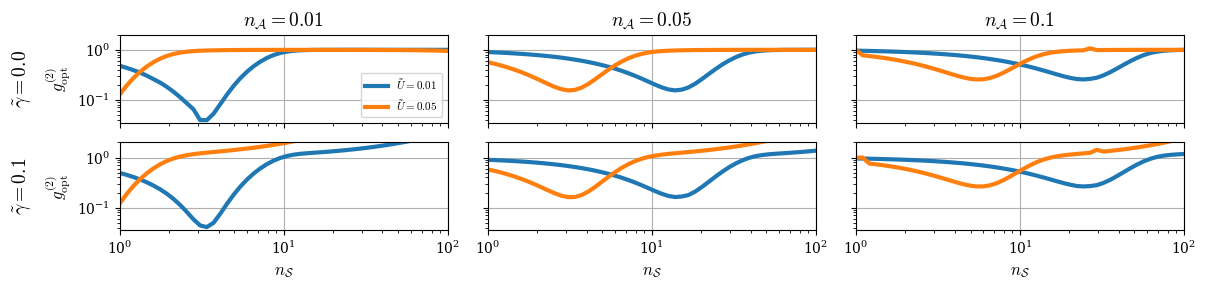

In [52]:
import matplotlib.pyplot as plt
from itertools import product

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'

n_out_plot = [0.01, 0.05, 0.1]
gamma_plot = [0., .1]
n_photon_plot = vec_n_photon
U_plot = [0.01, 0.05]

n_plot_x = len(n_out_plot)   # columns: n_out
n_plot_y = len(gamma_plot)   # rows: gamma

xaxis = n_photon_plot

fig, ax = plt.subplots(n_plot_y, n_plot_x, figsize=(4 * n_plot_x, 1.5 * n_plot_y), sharex=True, sharey=True)

for i, gamma in enumerate(gamma_plot):       # rows
    for j, n_out in enumerate(n_out_plot):   # columns

        for U in U_plot:
            dat_g2 = []
            for n_photon in n_photon_plot:
                dat_g2.append(results[(U, n_photon, n_out, gamma)]['g2'])

            ax[i, j].loglog(xaxis, dat_g2, "-", label=rf"$\tilde{{U}}={U}$", linewidth=3)

        ax[i, j].grid(True)
        ax[i, j].set_xlim([np.min(xaxis), np.max(xaxis)])
        ax[i, j].set_ylim([0.035, 2.])

        if j == 0:
            ax[i, j].set_ylabel(r"$g^{(2)}_\text{opt}$", fontsize=12)

        if i == n_plot_y - 1:
            ax[i, j].set_xlabel(r"$n_\mathcal{S}$", fontsize=12)

        # Upper titles: n_out values for each column
        if i == 0:
            ax[i, j].set_title(rf"$n_\mathcal{{A}}={n_out}$", fontsize=14, fontweight='bold')

    # Left titles: gamma values for each row
    ax[i, 0].annotate(
        rf"$\tilde{{\gamma}}={gamma:.1f}$",
        xy=(0, 0.5), xycoords='axes fraction',
        xytext=(-0.3, 0.5), textcoords='axes fraction',
        fontsize=14, ha='center', va='center', rotation=90, fontweight='bold'
    )

ax[0, 0].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

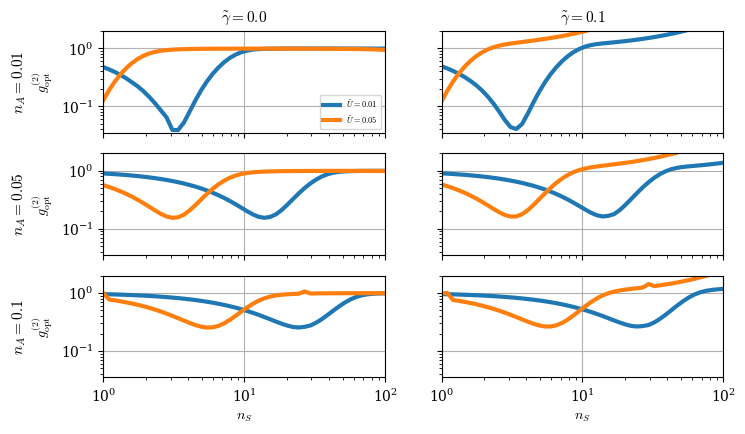

In [41]:
import matplotlib.pyplot as plt
from itertools import product

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'

n_out_plot = [0.01, 0.05, 0.1]
gamma_plot = gammas[:-1]
n_photon_plot = vec_n_photon
U_plot = [0.01, 0.05]

n_plot_x = len(gamma_plot)
n_plot_y = len(n_out_plot)

xaxis = n_photon_plot

fig, ax = plt.subplots(n_plot_y, n_plot_x, figsize=(4 * n_plot_x, 1.5 * n_plot_y), sharex=True, sharey=True)

for i, n_out in enumerate(n_out_plot):
    for j, gamma in enumerate(gamma_plot):

        for U in U_plot:
            dat_g2 = []
            for n_photon in n_photon_plot:
                dat_g2.append(results[(U, n_photon, n_out, gamma)]['g2'])

            ax[i, j].loglog(xaxis, dat_g2, "-", label=rf"$\tilde{{U}}={U}$", linewidth=3)

        ax[i, j].grid(True)
        ax[i, j].set_xlim([np.min(xaxis), np.max(xaxis)])
        ax[i, j].set_ylim([0.035, 2.])

        if j == 0:
            ax[i, j].set_ylabel(r"$g^{(2)}_\text{opt}$")

        if i == n_plot_y - 1:
            ax[i, j].set_xlabel(r"$n_S$")

        # Upper titles: gamma values for each column
        if i == 0:
            ax[i, j].set_title(rf"$\tilde{{\gamma}}={gamma:.1f}$", fontsize=11,fontweight='bold')

    # Left titles: n_out values for each row, rotated 90 degrees
    ax[i, 0].annotate(
        rf"$n_A={n_out}$",
        xy=(0, 0.5), xycoords='axes fraction',
        xytext=(-0.3, 0.5), textcoords='axes fraction',
        fontsize=11, ha='center', va='center', rotation=90, fontweight='bold'
    )

ax[0, 0].legend(fontsize=6, loc='lower right')

#fig.tight_layout()
plt.show()

 (n,gamma): (0.01, 0.0)
 (n,gamma): (0.01, 0.1)
 (n,gamma): (0.05, 0.0)
 (n,gamma): (0.05, 0.1)
 (n,gamma): (0.1, 0.0)
 (n,gamma): (0.1, 0.1)


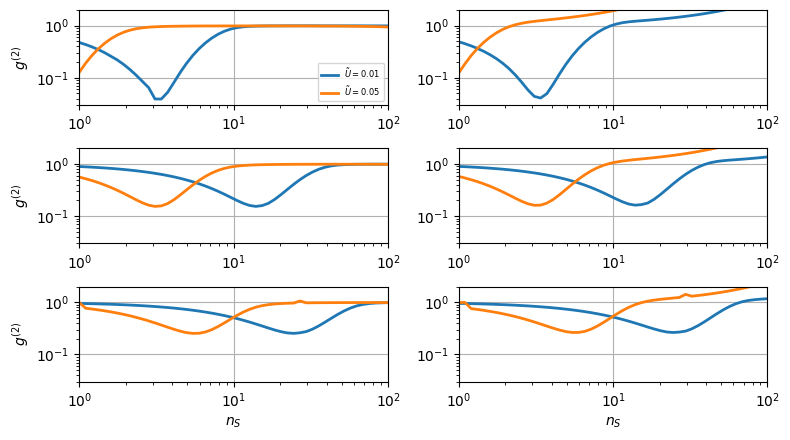

In [21]:
import matplotlib.pyplot as plt
from itertools import product

n_out_plot = [0.01, 0.05, 0.1]
gamma_plot = gammas[:-1]
n_photon_plot = vec_n_photon
U_plot = [0.01, 0.05]

n_plot_x = len(gamma_plot)
n_plot_y = len(n_out_plot)

xaxis = n_photon_plot

fig, ax = plt.subplots(n_plot_y, n_plot_x, figsize=(4 * n_plot_x, 1.5 * n_plot_y))

for i, n_out in enumerate(n_out_plot):
    for j, gamma in enumerate(gamma_plot):

        print(f" (n,gamma): {(n_out, gamma)}")
        for U in U_plot:
            dat_g2 = []
            for n_photon in n_photon_plot:
                dat_g2.append(results[(U, n_photon, n_out, gamma)]['g2'])

            ax[i,j].loglog(xaxis, dat_g2, "-", label=rf"$\tilde{{U}}={U}$", linewidth=2)

            ax[i,j].grid(True)
            ax[i,j].set_xlim([np.min(xaxis), np.max(xaxis)])
            ax[i,j].set_ylim([0.03, 2.])

            if j == 0:
                ax[i,j].set_ylabel(r"$g^{(2)}$")
            
            if i == n_plot_y - 1:
                ax[i,j].set_xlabel(r"$n_S$")

    
    ax[0,0].legend(fontsize=6, loc='lower right')

    plt.tight_layout()

 (n,gamma): (0.01, 0.0)
 (n,gamma): (0.01, 0.1)
 (n,gamma): (0.05, 0.0)
 (n,gamma): (0.05, 0.1)
 (n,gamma): (0.1, 0.0)
 (n,gamma): (0.1, 0.1)


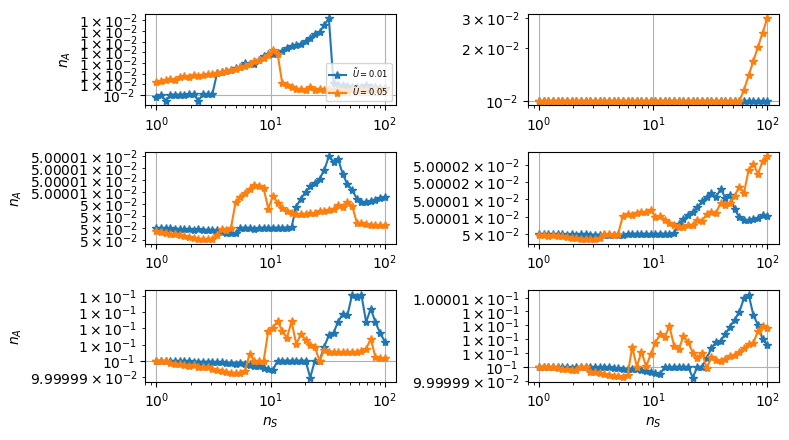

In [16]:
import matplotlib.pyplot as plt
from itertools import product

n_out_plot = [0.01, 0.05, 0.1]
gamma_plot = gammas[:-1]
n_photon_plot = vec_n_photon
U_plot = [0.01, 0.05]

n_plot_x = len(gamma_plot)
n_plot_y = len(n_out_plot)

xaxis = n_photon_plot

fig, ax = plt.subplots(n_plot_y, n_plot_x, figsize=(4 * n_plot_x, 1.5 * n_plot_y))

for i, n_out in enumerate(n_out_plot):
    for j, gamma in enumerate(gamma_plot):

        print(f" (n,gamma): {(n_out, gamma)}")
        for U in U_plot:
            dat_n = []
            for n_photon in n_photon_plot:
                dat_n.append(results[(U, n_photon, n_out, gamma)]['na'])

            ax[i,j].loglog(xaxis, dat_n, "*-", label=rf"$\tilde{{U}}={U}$")

            ax[i,j].grid(True)
            # ax[i,j].set_xlim([np.min(xaxis), np.max(xaxis)])
            # ax[i,j].set_ylim([0.03, 10.])

            if j == 0:
                ax[i,j].set_ylabel(r"$n_A$")
            
            if i == n_plot_y - 1:
                ax[i,j].set_xlabel(r"$n_S$")

    
    ax[0,0].legend(fontsize=6, loc='lower right')

    plt.tight_layout()

# Dependence nonlinearity

# analyze resilience

In [3]:
from scipy.integrate import solve_ivp

def get_g2(alpha, N, M):
    n_alpha = np.abs(alpha) ** 2

    numerator = (
        n_alpha ** 2
        + 4 * N * n_alpha
        + M * alpha.conj() ** 2
        + M.conj() * alpha ** 2
        + 2 * N ** 2
        + M * M.conj()
    )
    denominator = n_alpha ** 2 + 2 * N * n_alpha + N ** 2
    g2 = numerator / denominator

    return g2.real

def solve_ODE_AS_mode(
    J, 
    U_ns, 
    alpha_0, 
    tlist, 
    Delta=0.,
    gamma=0.
    ):

  def dF(t, v):

    # extract alpha, N, M from vector
    alpha, N, M = v[0], v[1], v[2]

    # compute differentials
    d_alpha = (-gamma/2. - 1j*Delta) * alpha \
        -2j * J * alpha - 1j * 0.5 * U_ns * alpha - 1j * 0.5 * U_ns * alpha.conj()
    d_N = -gamma * N - U_ns * M.imag
    d_M = (-gamma - 2j*Delta) * M \
        -4j * J * M - 1j * U_ns * M - 1j * U_ns * (N + 0.5)

    # return differentials in array format
    return np.array([d_alpha, d_N, d_M])

  # solve the system, with right initial state
  y0 = np.array([alpha_0, 0, 0])
  sol = solve_ivp(dF, [tlist[0], tlist[-1]], y0=y0, t_eval=tlist)

  # return alpha, N, M tuple
  return sol.y[0], sol.y[1], sol.y[2]

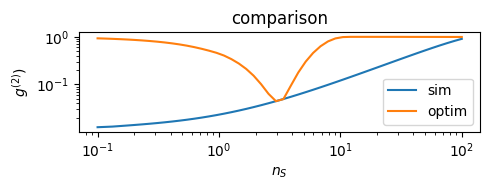

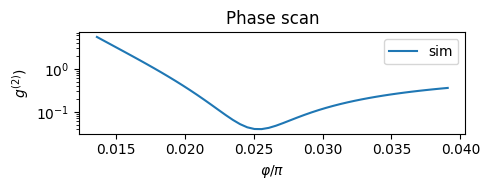

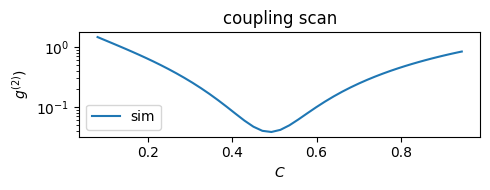

In [4]:


U = 0.01
n_out_tar = 0.01
gamma = 0.

vec_g2 = [results[(U, ns, n_out_tar, gamma)]['g2'] for ns in vec_ns]
ind = np.argmin(vec_g2)
g2_min = np.min(vec_g2)
ns_min = float(vec_ns[ind])
res = results[(U, ns_min, n_out_tar, gamma)]
phase_min = res['phase']
coupling_min = res['coupling']

phase_scan = np.linspace(-0.04, 0.04, 50)
coupling_scan = np.linspace(-np.pi/6, np.pi/6)

# comparison with optimization

plt.figure(figsize=(5,2))
vec_g2_sim = []
for ns in vec_ns:
    alpha_0 = 1j * res['phase'] * np.sqrt(ns) / np.sqrt(2)
    alpha, N, M = solve_ODE_AS_mode(J=res['coupling'], U_ns=U * ns, alpha_0=alpha_0, tlist=[0.,1.], gamma=gamma)

    g2 = get_g2(alpha[-1], N[-1], M[-1])
    vec_g2_sim.append(g2)

plt.loglog(vec_ns, vec_g2_sim, label='sim')
plt.loglog(vec_ns, vec_g2, label='optim')

plt.legend()
plt.xlabel(r"$n_S$")
plt.ylabel(r"$g^{(2)})$")
plt.title('comparison')
plt.tight_layout()
plt.show()

# phase scan

plt.figure(figsize=(5,2))
vec_g2_phase = []
for phase in phase_scan:
    alpha_0 = 1j * (phase + phase_min) * np.sqrt(ns_min) / np.sqrt(2)
    alpha, N, M = solve_ODE_AS_mode(J=res['coupling'], U_ns=U * ns_min, alpha_0=alpha_0, tlist=[0.,1.], gamma=gamma)

    g2 = get_g2(alpha[-1], N[-1], M[-1])
    vec_g2_phase.append(g2)

plt.semilogy((phase_scan + phase_min)/np.pi, vec_g2_phase, label='sim')
plt.legend()
plt.xlabel(r"$\varphi/\pi$")
plt.ylabel(r"$g^{(2)})$")
plt.title('Phase scan')
plt.tight_layout()
plt.show()

# scan coupling
plt.figure(figsize=(5,2))
vec_g2_coupling = []
for coupling in coupling_scan:
    alpha_0 = 1j * phase_min* np.sqrt(ns_min) / np.sqrt(2)
    alpha, N, M = solve_ODE_AS_mode(J=coupling + coupling_min, U_ns=U * ns_min, alpha_0=alpha_0, tlist=[0.,1.], gamma=gamma)

    g2 = get_g2(alpha[-1], N[-1], M[-1])
    vec_g2_coupling.append(g2)

plt.semilogy(np.sin(coupling_scan + coupling_min) ** 2, vec_g2_coupling, label='sim')
plt.legend()
plt.xlabel(r"$C$")
plt.ylabel(r"$g^{(2)})$")
plt.title('coupling scan')
plt.tight_layout()
plt.show()

# AS occupation check

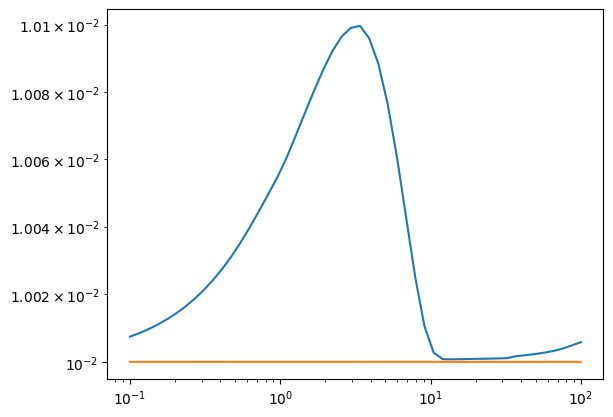

In [5]:
U = 0.01
n_out_tar = 0.01
gamma = 0.

vec_phase = np.array([results[(U, ns, n_out_tar, gamma)]['phase'] for ns in vec_ns])
vec_alpha = np.array([results[(U, ns, n_out_tar, gamma)]['alpha'] for ns in vec_ns])
vec_N = np.array([results[(U, ns, n_out_tar, gamma)]['N'] for ns in vec_ns])

na_phase = 0.5 * vec_phase ** 2 * vec_ns
na_meas = np.abs(vec_alpha) ** 2 + vec_N

plt.loglog(vec_ns, na_phase)
# plt.semilogy(vec_ns, vec_ns)
plt.loglog(vec_ns, na_meas)

In [ ]:
np.argmax(vec_phase)

np.int64(0)

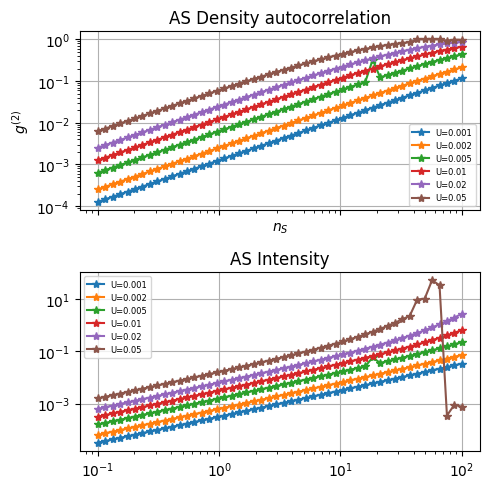

<Figure size 500x200 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

n_out_tar = None
gamma = 0.

fig, ax = plt.subplots(2,1, figsize=(5,5), sharex=True)
for U in vec_U[:-1]:
    dat_g2 = []
    for ns in vec_ns:
        dat_g2.append(results[(U, ns, n_out_tar, gamma)]['g2'])

    ax[0].loglog(vec_ns, dat_g2, "*-", label=f"U={U}")

#plt.ylim(0,0.3)
ax[0].grid(True)
ax[0].legend(fontsize=6)
ax[0].set_title("AS Density autocorrelation")
ax[0].set_ylabel(r"$g^{(2)}$")

plt.figure(figsize=(5,2))
for U in vec_U[:-1]:
    dat_n_out = []
    for ns in vec_ns:
        n_out = np.abs(results[(U, ns, n_out_tar, gamma)]['alpha']) ** 2 \
            + np.abs(results[(U, ns, n_out_tar, gamma)]['N'])
        dat_n_out.append(n_out)

    ax[1].loglog(vec_ns, dat_n_out, "*-", label=f"U={U}")

ax[1].grid(True)
ax[1].legend(fontsize=6)
ax[0].set_xlabel(r"$n_S$")
ax[1].set_title("AS Intensity")

fig.tight_layout()

In [ ]:
results[(vec_U[0],vec_ns[0])]['g2']

np.complex128(0.19651278031228242+0j)